In [1]:
# LJSpeech Dataset - Exploratory Data Analysis
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# LJSpeech Dataset - Exploratory Data Analysis

## Dataset Overview
The LJ Speech Dataset is a public domain speech dataset consisting of 13,100 short audio clips of a single speaker reading passages from 7 non-fiction books. Each clip includes a transcription.

**Key Features:**
- Total Clips: 13,100
- Single speaker
- Audio Format: Single-channel 16-bit PCM WAV at 22050 Hz
- Duration: Approximately 24 hours total
- Published texts from 1884-1964

## 1. Load and Inspect Metadata

In [2]:
# Define paths
DATASET_PATH = '../LJSpeech-1.1'
METADATA_PATH = os.path.join(DATASET_PATH, 'metadata.csv')
WAVS_PATH = os.path.join(DATASET_PATH, 'wavs')

print(f"Dataset path: {DATASET_PATH}")
print(f"Metadata path: {METADATA_PATH}")
print(f"Wavs path: {WAVS_PATH}")
print(f"\nChecking paths exist:")
print(f"  Dataset exists: {os.path.exists(DATASET_PATH)}")
print(f"  Metadata exists: {os.path.exists(METADATA_PATH)}")
print(f"  Wavs folder exists: {os.path.exists(WAVS_PATH)}")

Dataset path: ../LJSpeech-1.1
Metadata path: ../LJSpeech-1.1/metadata.csv
Wavs path: ../LJSpeech-1.1/wavs

Checking paths exist:
  Dataset exists: True
  Metadata exists: True
  Wavs folder exists: True


## 2. Basic Dataset Information

In [3]:
# Load metadata (pipe-delimited CSV)
df = pd.read_csv(METADATA_PATH, sep='|', header=None, 
                 names=['file_id', 'transcription', 'normalized_transcription'])

print(f"Total number of samples: {len(df)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)

Total number of samples: 13100

Dataset shape: (13100, 3)

Column names: ['file_id', 'transcription', 'normalized_transcription']

First few rows:


,file_id,transcription,normalized_transcription
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...
5,LJ001-0006,"And it is worth mention in passing that, as an...","And it is worth mention in passing that, as an..."
6,LJ001-0007,"the earliest book printed with movable types, ...","the earliest book printed with movable types, ..."
7,LJ001-0008,has never been surpassed.,has never been surpassed.
8,LJ001-0009,"Printing, then, for our purpose, may be consid...","Printing, then, for our purpose, may be consid..."
9,LJ001-0010,"Now, as all books not primarily intended as pi...","Now, as all books not primarily intended as pi..."


In [4]:
# Basic information
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nBasic Statistics:")
df.describe(include='all')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 13100 entries, 0 to 13099
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   file_id                   13100 non-null  str  
 1   transcription             13100 non-null  str  
 2   normalized_transcription  13084 non-null  str  
dtypes: str(3)
memory usage: 307.2 KB
None


Missing Values:
file_id                      0
transcription                0
normalized_transcription    16
dtype: int64


Basic Statistics:


,file_id,transcription,normalized_transcription
count,13100,13100,13084
unique,13100,13074,13058
top,LJ001-0001,Report of the President's Commission on the As...,Report of the President's Commission on the As...
freq,1,12,12


## 3. Text Analysis

Text Length Statistics:
        text_length    word_count    char_count
count  13084.000000  13084.000000  13084.000000
mean      99.872057     16.984332     99.872057
std       33.954024      6.063726     33.954024
min       12.000000      1.000000     12.000000
25%       76.000000     13.000000     76.000000
50%      102.000000     17.000000    102.000000
75%      126.000000     21.000000    126.000000
max      187.000000     39.000000    187.000000


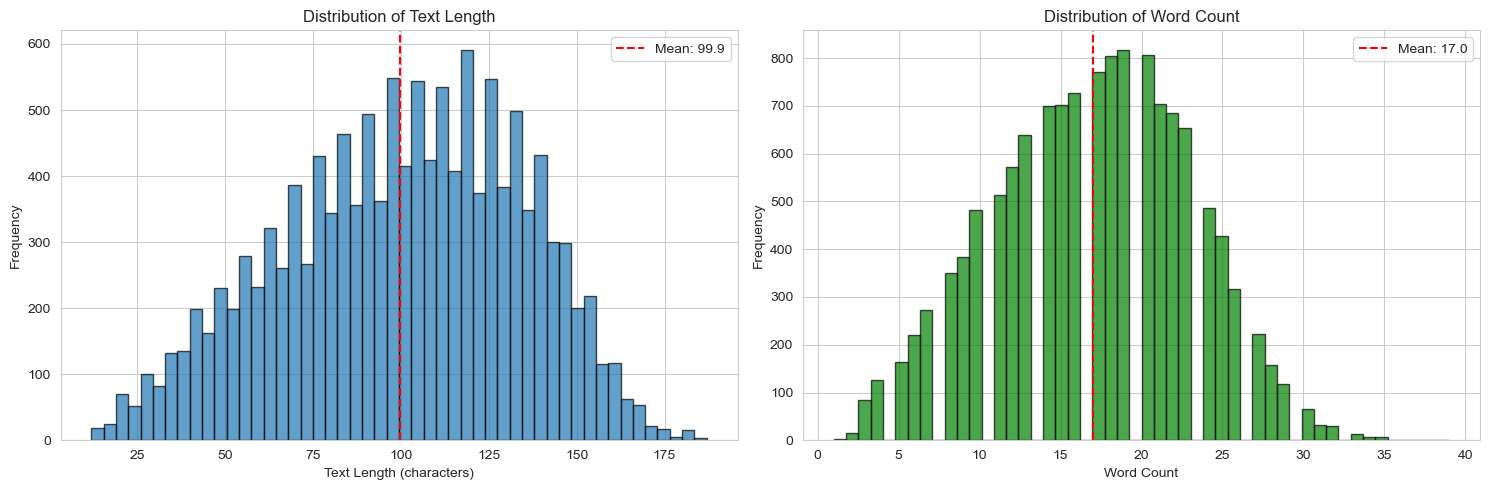

In [5]:
# Calculate text statistics
df['text_length'] = df['normalized_transcription'].str.len()
df['word_count'] = df['normalized_transcription'].str.split().str.len()
df['char_count'] = df['normalized_transcription'].str.len()

# Summary statistics
print("Text Length Statistics:")
print(df[['text_length', 'word_count', 'char_count']].describe())

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length')
axes[0].axvline(df['text_length'].mean(), color='r', linestyle='--', label=f'Mean: {df["text_length"].mean():.1f}')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count')
axes[1].axvline(df['word_count'].mean(), color='r', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Find longest and shortest texts
print("Top 5 longest texts:")
longest_idx = df['text_length'].nlargest(5).index
for idx in longest_idx:
    print(f"\n{df.loc[idx, 'file_id']}: {df.loc[idx, 'word_count']} words")
    print(f"  {df.loc[idx, 'normalized_transcription'][:150]}...")

print("\n" + "="*80)
print("\nTop 5 shortest texts:")
shortest_idx = df['text_length'].nsmallest(5).index
for idx in shortest_idx:
    print(f"\n{df.loc[idx, 'file_id']}: {df.loc[idx, 'word_count']} words")
    print(f"  {df.loc[idx, 'normalized_transcription']}")

Top 5 longest texts:

LJ038-0050: 32.0 words
  they might have heard a snapping noise resulting from the police officer grabbing the cylinder of the revolver and pulling it away from Oswald while h...

LJ048-0025: 37.0 words
  and had told Mrs. Paine that when he got the money he was going to take an apartment, when the baby was old enough, he was going to take an apartment,...

LJ007-0070: 29.0 words
  and that he had again and again protested against the obstacles thrown in his way, the inspectors "cannot forbear expressing their opinion that he mig...

LJ036-0138: 36.0 words
  But when I got pretty close to five hundred block at Neches and North Beckley which is the five hundred block, he said, "This will do fine," and I pul...

LJ029-0001: 25.0 words
  Report of the President's Commission on the Assassination of President Kennedy. The Warren Commission Report. By The President's Commission on the Ass...


Top 5 shortest texts:

LJ037-0003: 1.0 words
  Eyewitnesses

LJ043-0159: 2.0 

Total words: 222,223
Unique words: 22,848
Vocabulary size: 22,848

Top 20 most common words:
  the            : 18280 occurrences
  of             :  8698 occurrences
  and            :  6385 occurrences
  to             :  6275 occurrences
  in             :  4772 occurrences
  a              :  4282 occurrences
  was            :  3729 occurrences
  that           :  2888 occurrences
  he             :  2712 occurrences
  his            :  2021 occurrences
  for            :  1777 occurrences
  on             :  1768 occurrences
  had            :  1629 occurrences
  as             :  1587 occurrences
  with           :  1524 occurrences
  by             :  1519 occurrences
  at             :  1464 occurrences
  were           :  1433 occurrences
  it             :  1365 occurrences
  which          :  1301 occurrences


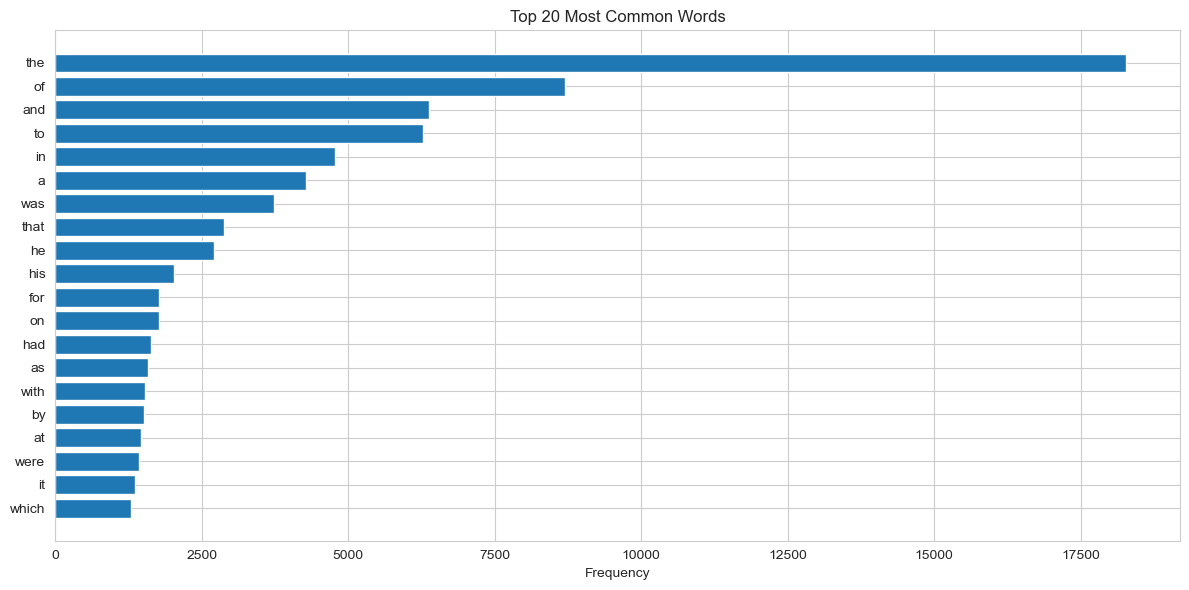

In [8]:
# Vocabulary analysis
# Filter out NaN values before processing
all_words = ' '.join(df['normalized_transcription'].dropna().astype(str).values).lower().split()
unique_words = set(all_words)

print(f"Total words: {len(all_words):,}")
print(f"Unique words: {len(unique_words):,}")
print(f"Vocabulary size: {len(unique_words):,}")

# Most common words
from collections import Counter
word_freq = Counter(all_words)
most_common = word_freq.most_common(20)

print("\nTop 20 most common words:")
for word, count in most_common:
    print(f"  {word:15s}: {count:5d} occurrences")

# Visualize top words
words, counts = zip(*most_common)
plt.figure(figsize=(12, 6))
plt.barh(range(len(words)), counts)
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Audio Analysis

In [9]:
# Sample a subset of audio files to analyze (analyzing all 13k files would take too long)
# Let's analyze a representative sample
import random
random.seed(42)

SAMPLE_SIZE = 100  # Adjust this based on your needs
sample_indices = random.sample(range(len(df)), min(SAMPLE_SIZE, len(df)))

print(f"Analyzing {len(sample_indices)} audio files out of {len(df)} total...")
print("This may take a few moments...")

audio_stats = []
for i, idx in enumerate(sample_indices):
    if i % 20 == 0:
        print(f"  Processing {i}/{len(sample_indices)}...")
    
    file_id = df.loc[idx, 'file_id']
    audio_path = os.path.join(WAVS_PATH, f"{file_id}.wav")
    
    if os.path.exists(audio_path):
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)
            
            # Calculate statistics
            audio_stats.append({
                'file_id': file_id,
                'duration': duration,
                'sample_rate': sr,
                'samples': len(y),
                'rms_energy': np.sqrt(np.mean(y**2)),
                'word_count': df.loc[idx, 'word_count']
            })
        except Exception as e:
            print(f"Error processing {file_id}: {e}")
    else:
        print(f"File not found: {audio_path}")

audio_df = pd.DataFrame(audio_stats)
print(f"\nSuccessfully analyzed {len(audio_df)} audio files")

Analyzing 100 audio files out of 13100 total...
This may take a few moments...
  Processing 0/100...
  Processing 20/100...
  Processing 40/100...
  Processing 60/100...
  Processing 80/100...

Successfully analyzed 100 audio files


Audio Duration Statistics (from sample):
count    100.000000
mean       6.327127
std        2.157221
min        1.214558
25%        4.758503
50%        6.410023
75%        7.867075
max       10.038141
Name: duration, dtype: float64


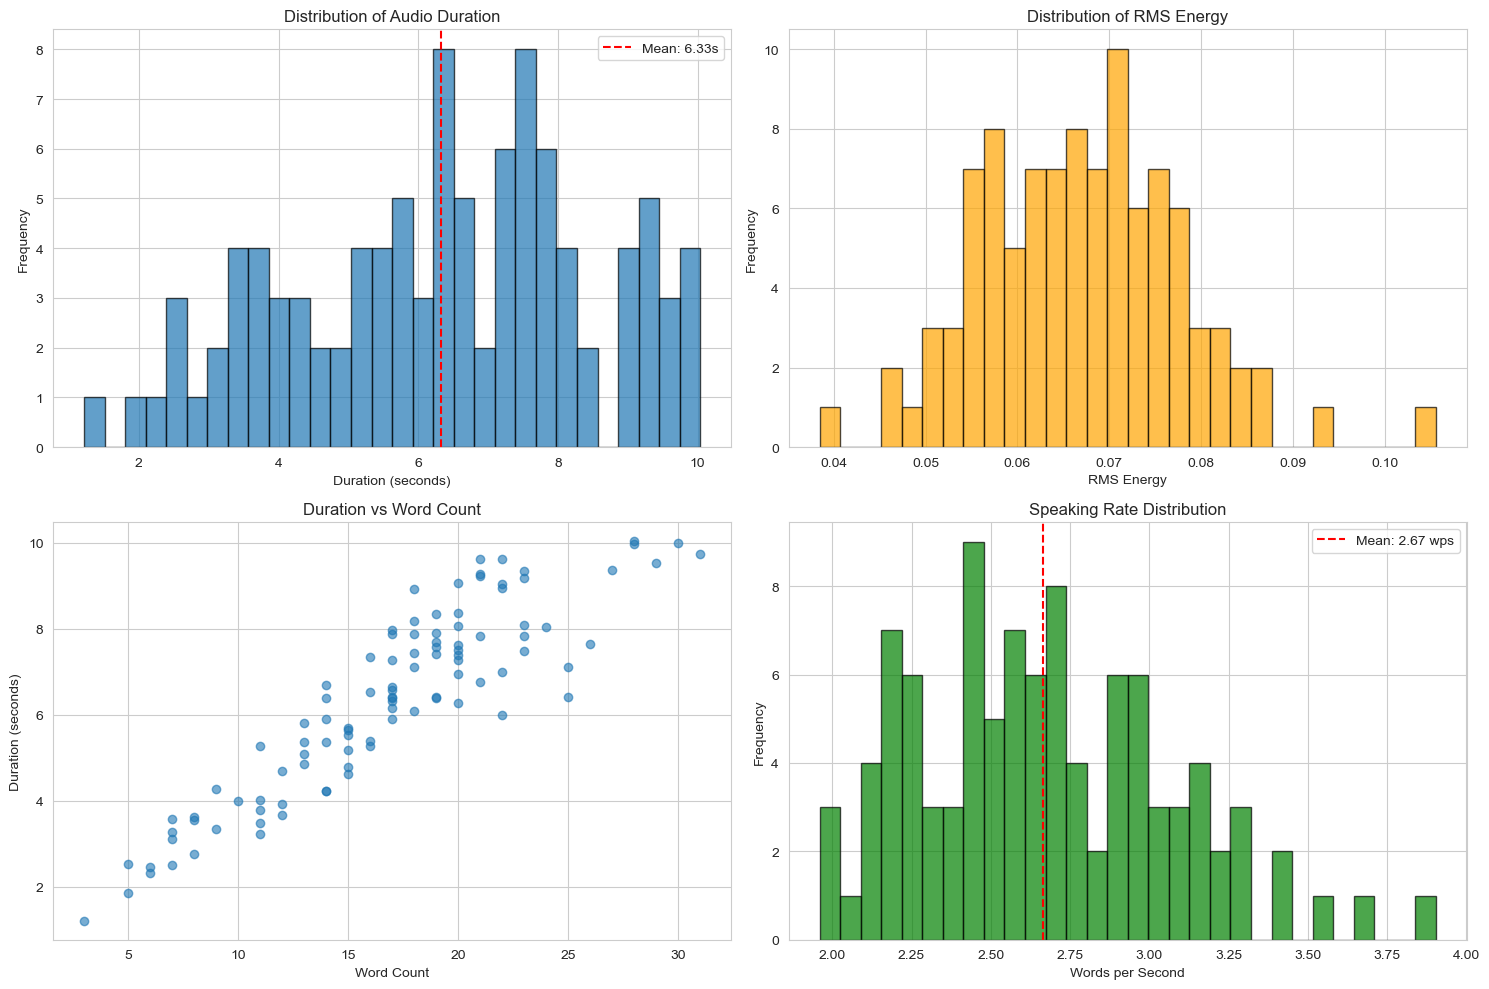


Average speaking rate: 2.67 words per second


In [10]:
# Audio duration statistics
print("Audio Duration Statistics (from sample):")
print(audio_df['duration'].describe())

# Visualize audio duration distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Duration distribution
axes[0, 0].hist(audio_df['duration'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Audio Duration')
axes[0, 0].axvline(audio_df['duration'].mean(), color='r', linestyle='--', 
                    label=f'Mean: {audio_df["duration"].mean():.2f}s')
axes[0, 0].legend()

# RMS Energy distribution
axes[0, 1].hist(audio_df['rms_energy'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('RMS Energy')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of RMS Energy')

# Duration vs Word Count
axes[1, 0].scatter(audio_df['word_count'], audio_df['duration'], alpha=0.6)
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Duration (seconds)')
axes[1, 0].set_title('Duration vs Word Count')

# Calculate speaking rate
audio_df['speaking_rate'] = audio_df['word_count'] / audio_df['duration']
axes[1, 1].hist(audio_df['speaking_rate'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Words per Second')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Speaking Rate Distribution')
axes[1, 1].axvline(audio_df['speaking_rate'].mean(), color='r', linestyle='--', 
                    label=f'Mean: {audio_df["speaking_rate"].mean():.2f} wps')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage speaking rate: {audio_df['speaking_rate'].mean():.2f} words per second")

## 5. Visualize Sample Waveforms and Spectrograms

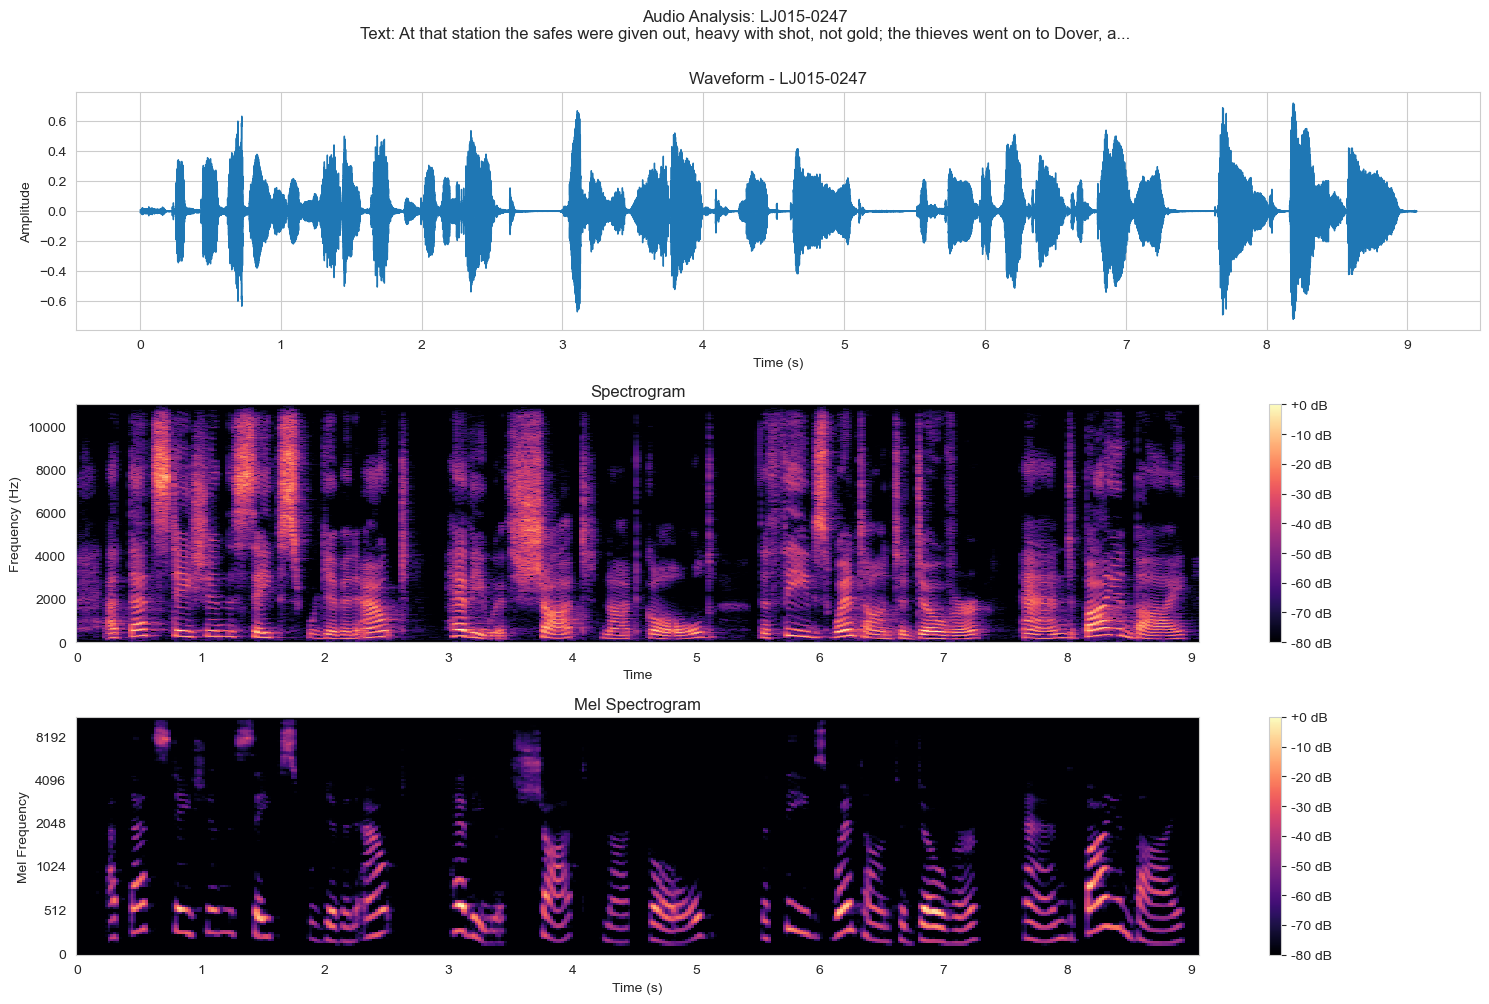


File: LJ015-0247
Duration: 9.06 seconds
Sample rate: 22050 Hz
Transcription: At that station the safes were given out, heavy with shot, not gold; the thieves went on to Dover, and by-and-by,



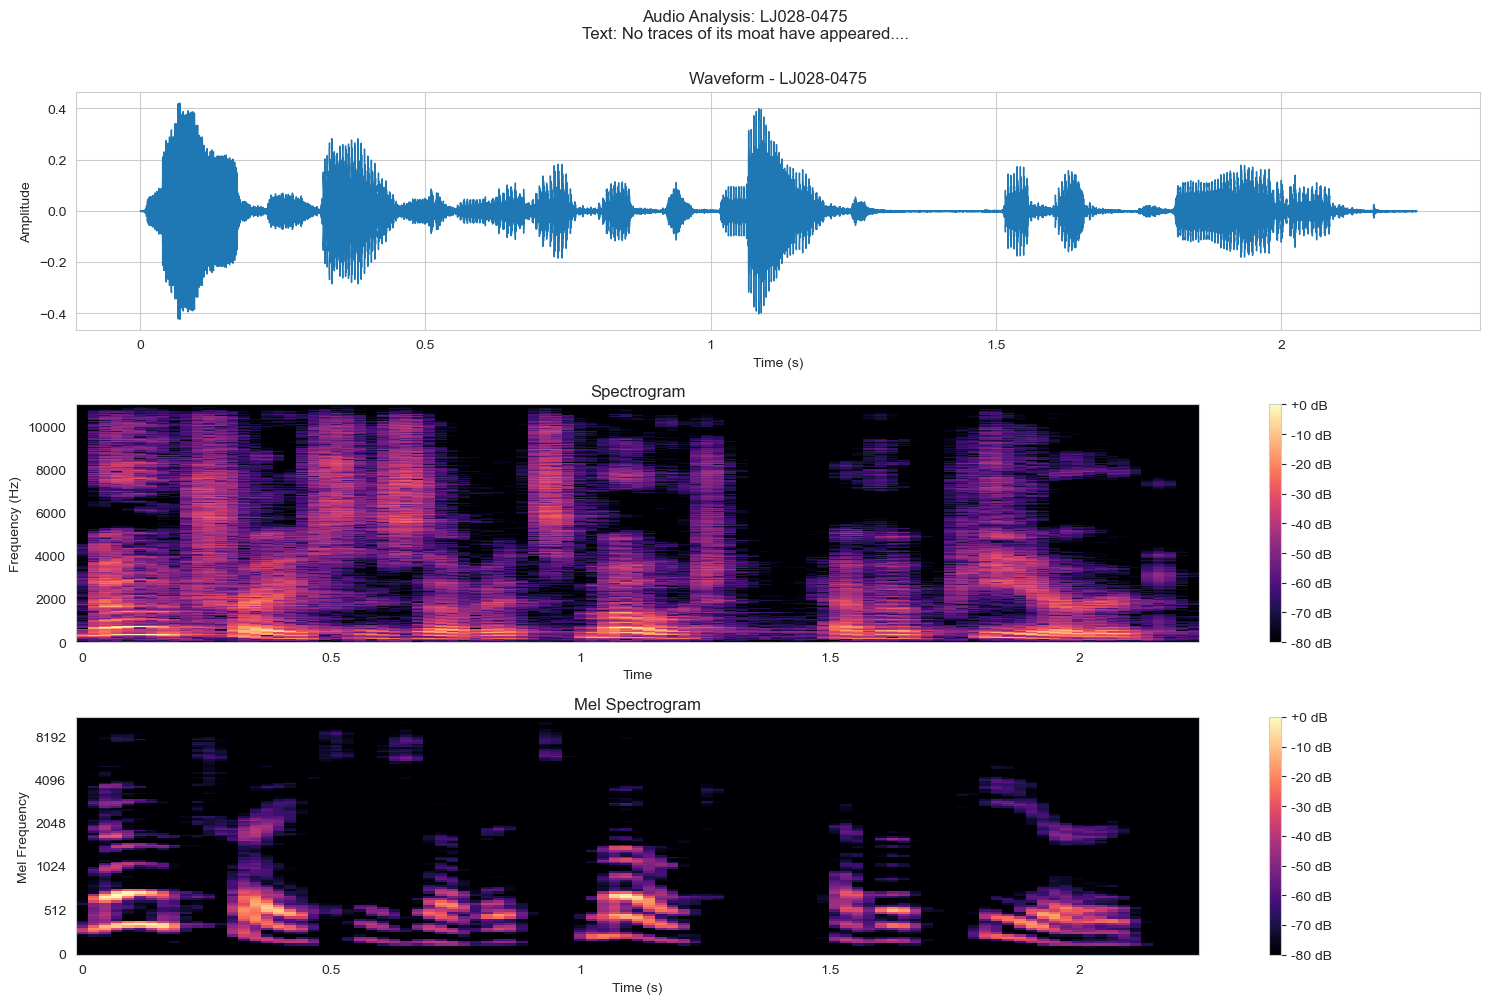


File: LJ028-0475
Duration: 2.24 seconds
Sample rate: 22050 Hz
Transcription: No traces of its moat have appeared.



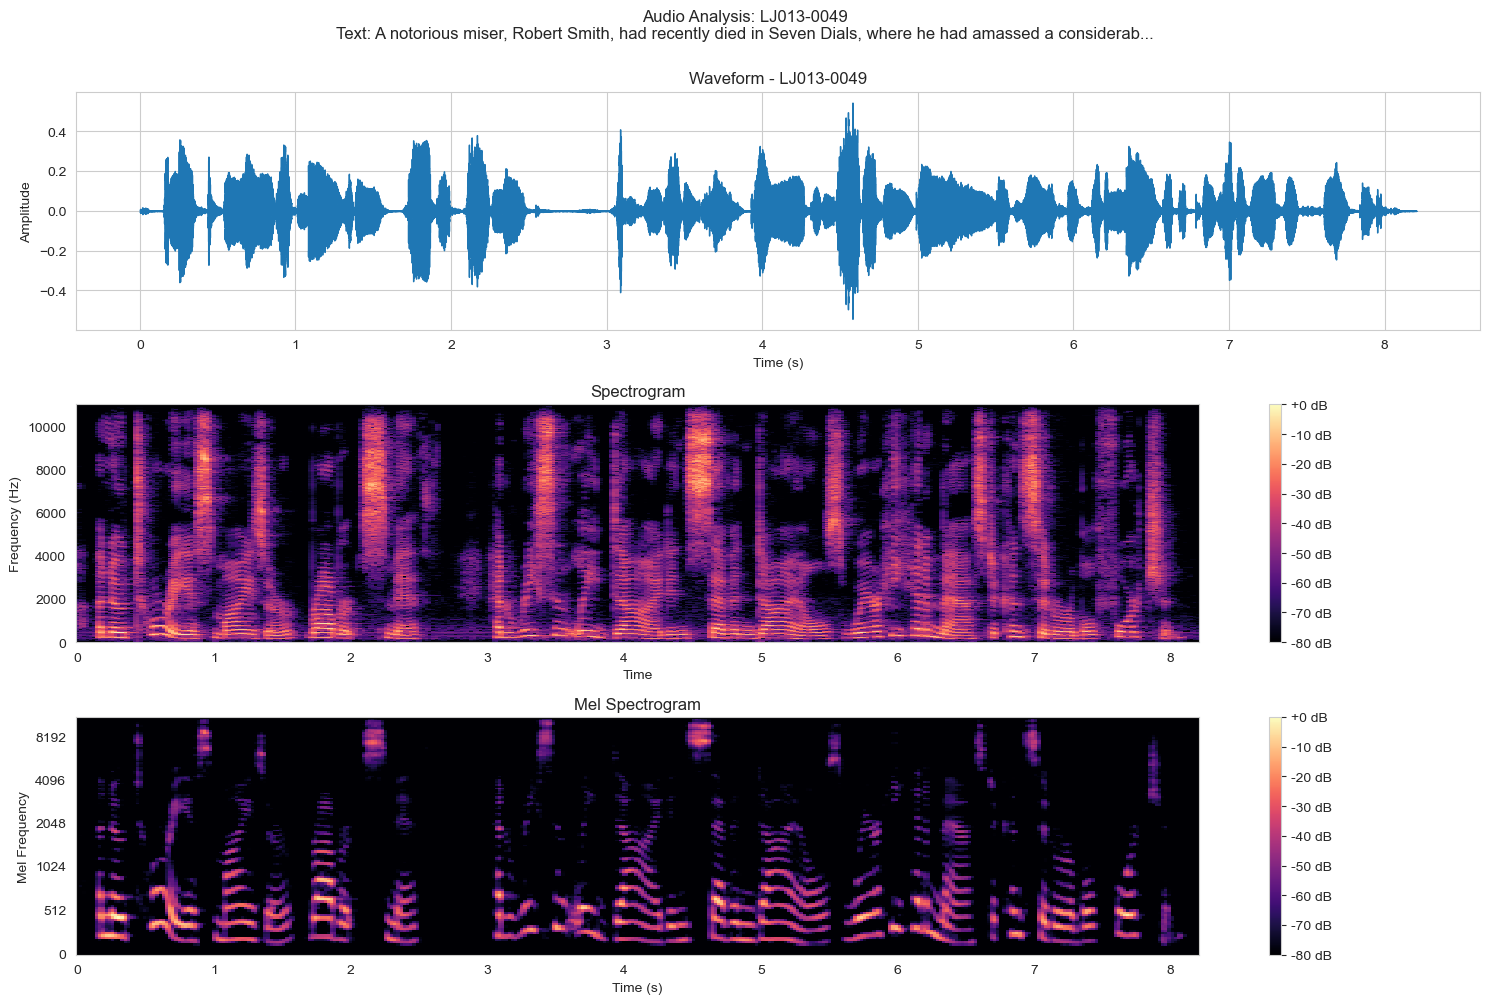


File: LJ013-0049
Duration: 8.20 seconds
Sample rate: 22050 Hz
Transcription: A notorious miser, Robert Smith, had recently died in Seven Dials, where he had amassed a considerable fortune.



In [12]:
# Visualize a few sample audio files
num_samples_to_plot = 3
sample_files = df.sample(num_samples_to_plot, random_state=42)

for idx, row in sample_files.iterrows():
    file_id = row['file_id']
    audio_path = os.path.join(WAVS_PATH, f"{file_id}.wav")
    
    if not os.path.exists(audio_path):
        print(f"File not found: {audio_path}")
        continue
    
    # Load audio
    y, sr = librosa.load(audio_path, sr=None)
    
    # Create figure with subplots
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'Waveform - {file_id}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    
    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title('Spectrogram')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2])
    axes[2].set_title('Mel Spectrogram')
    axes[2].set_ylabel('Mel Frequency')
    axes[2].set_xlabel('Time (s)')
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')
    
    plt.suptitle(f"Audio Analysis: {file_id}\nText: {row['normalized_transcription'][:100]}...", 
                 fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFile: {file_id}")
    print(f"Duration: {librosa.get_duration(y=y, sr=sr):.2f} seconds")
    print(f"Sample rate: {sr} Hz")
    print(f"Transcription: {row['normalized_transcription']}")
    print("="*80 + "\n")

## 6. Summary and Key Findings

In [13]:
# Check for missing audio files
print("Checking for missing audio files...")
missing_files = []
existing_files = []

for idx, row in df.iterrows():
    file_id = row['file_id']
    audio_path = os.path.join(WAVS_PATH, f"{file_id}.wav")
    
    if not os.path.exists(audio_path):
        missing_files.append(file_id)
    else:
        existing_files.append(file_id)

print(f"Total metadata entries: {len(df)}")
print(f"Existing audio files: {len(existing_files)}")
print(f"Missing audio files: {len(missing_files)}")

if missing_files:
    print(f"\nFirst 10 missing files:")
    for f in missing_files[:10]:
        print(f"  {f}")
else:
    print("\n✓ All audio files are present!")

Checking for missing audio files...
Total metadata entries: 13100
Existing audio files: 13100
Missing audio files: 0

✓ All audio files are present!


In [14]:
# Check for duplicate transcriptions
duplicate_transcriptions = df[df.duplicated('normalized_transcription', keep=False)]
print(f"Number of duplicate transcriptions: {len(duplicate_transcriptions)}")

if len(duplicate_transcriptions) > 0:
    print(f"\nSample duplicate transcriptions:")
    print(duplicate_transcriptions.groupby('normalized_transcription').size().head(10))
else:
    print("No duplicate transcriptions found.")

# Check for empty or very short transcriptions
empty_transcriptions = df[df['normalized_transcription'].str.len() < 10]
print(f"\nNumber of very short transcriptions (< 10 chars): {len(empty_transcriptions)}")
if len(empty_transcriptions) > 0:
    print(empty_transcriptions[['file_id', 'normalized_transcription']].head())

Number of duplicate transcriptions: 52

Sample duplicate transcriptions:
normalized_transcription
According to Secretary Dillon,                                                                                                                                                             2
And two other justices agreed with him.                                                                                                                                                    2
Report of the President's Commission on the Assassination of President Kennedy.                                                                                                            8
Report of the President's Commission on the Assassination of President Kennedy. The Warren Commission Report. By The President's Commission on the Assassination of President Kennedy.    12
The Commission believes, however,                                                                                                                 

In [15]:
# Create comprehensive summary
print("=" * 80)
print(" " * 20 + "LJSPEECH DATASET SUMMARY")
print("=" * 80)
print()

print("📊 DATASET SIZE:")
print(f"   Total samples: {len(df):,}")
print(f"   Audio files present: {len(existing_files):,}")
print()

print("📝 TEXT STATISTICS:")
print(f"   Average text length: {df['text_length'].mean():.1f} characters")
print(f"   Average word count: {df['word_count'].mean():.1f} words")
print(f"   Min words: {df['word_count'].min()}")
print(f"   Max words: {df['word_count'].max()}")
print(f"   Total unique words: {len(unique_words):,}")
print(f"   Total word occurrences: {len(all_words):,}")
print()

if len(audio_df) > 0:
    print("🎵 AUDIO STATISTICS (from sample):")
    print(f"   Average duration: {audio_df['duration'].mean():.2f} seconds")
    print(f"   Min duration: {audio_df['duration'].min():.2f} seconds")
    print(f"   Max duration: {audio_df['duration'].max():.2f} seconds")
    print(f"   Average speaking rate: {audio_df['speaking_rate'].mean():.2f} words/second")
    print(f"   Sample rate: {audio_df['sample_rate'].iloc[0]} Hz")
    print()

    # Estimate total duration
    estimated_total_duration = df['word_count'].mean() / audio_df['speaking_rate'].mean()
    total_hours = (estimated_total_duration * len(df)) / 3600
    print(f"📏 ESTIMATED DATASET TOTALS:")
    print(f"   Estimated total duration: ~{total_hours:.1f} hours")
    print()

print("✅ DATA QUALITY:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Duplicate transcriptions: {len(duplicate_transcriptions)}")
print(f"   Very short texts (< 10 chars): {len(empty_transcriptions)}")
print()

print("=" * 80)

                    LJSPEECH DATASET SUMMARY

📊 DATASET SIZE:
   Total samples: 13,100
   Audio files present: 13,100

📝 TEXT STATISTICS:
   Average text length: 99.9 characters
   Average word count: 17.0 words
   Min words: 1.0
   Max words: 39.0
   Total unique words: 22,848
   Total word occurrences: 222,223

🎵 AUDIO STATISTICS (from sample):
   Average duration: 6.33 seconds
   Min duration: 1.21 seconds
   Max duration: 10.04 seconds
   Average speaking rate: 2.67 words/second
   Sample rate: 22050 Hz

📏 ESTIMATED DATASET TOTALS:
   Estimated total duration: ~23.2 hours

✅ DATA QUALITY:
   Missing values: 64
   Duplicate transcriptions: 52
   Very short texts (< 10 chars): 0

